# FinBERT rsLoRA Finetuning (sentiment_dataset.csv)

Este notebook realiza **finetuning usando rsLoRA** (entrenando todos los parámetros) de `ProsusAI/finbert` para clasificación de sentimiento financiero con 3 clases: **negativo, neutral, positivo**.

In [5]:
# Instalación de dependencias requeridas
%pip install transformers torch datasets pandas scikit-learn peft

In [6]:
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [7]:
# Carga del dataset desde data/sentiment_dataset.csv
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset.csv"))
df = pd.read_csv(DATA_PATH)
df.head()

,text,sentiment,source
0,"Would Xiamen International Port Co., Ltd (HKG:...",neutral,twitter
1,Goldman Sachs stock price target raised to $36...,positive,twitter
2,Nike to record $425 mln charge as it transitio...,negative,twitter
3,Ocean impact investment fund reaches $92m seco...,neutral,twitter
4,Last day to sign up for a discount to our comm...,neutral,twitter


In [8]:
# Preparación de datos
df = df[["text", "sentiment"]].copy()
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"] != ""]
df = df[df["sentiment"].isin(LABEL2ID.keys())]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

# Mapeo de sentimientos a índices numéricos
df["label"] = df["sentiment"].map(LABEL2ID).astype(int)

df.head()

,text,sentiment,label
0,"Would Xiamen International Port Co., Ltd (HKG:...",neutral,1
1,Goldman Sachs stock price target raised to $36...,positive,2
2,Nike to record $425 mln charge as it transitio...,negative,0
3,Ocean impact investment fund reaches $92m seco...,neutral,1
4,Last day to sign up for a discount to our comm...,neutral,1


In [9]:
# Split estratificado: train 80%, valid 10%, test 10%
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
print("Ratios:", len(train_df)/len(df), len(val_df)/len(df), len(test_df)/len(df))

Shapes: (13004, 3) (1625, 3) (1626, 3)
Ratios: 0.8 0.09996924023377422 0.10003075976622577


In [10]:
# Creación de datasets compatibles con HuggingFace
train_ds = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok = val_ds.map(tokenize_batch, batched=True)
test_tok = test_ds.map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]
if "token_type_ids" in train_tok.column_names:
    cols.append("token_type_ids")

train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/13004 [00:00<?, ? examples/s]

Map:   0%|          | 0/1625 [00:00<?, ? examples/s]

Map:   0%|          | 0/1626 [00:00<?, ? examples/s]

In [11]:
# Configuración del modelo FinBERT (3 labels => 3 logits)
from peft import get_peft_model, LoraConfig, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=8,
    lora_dropout=0.1,
    bias="none",
    target_modules=["query", "value"],
    use_rslora=True,  # ← ESTO HABILITA rsLoRA
    inference_mode=False,
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

model = get_peft_model(model, lora_config)

print(f"Número de etiquetas del modelo: {model.config.num_labels}")
print(f"id2label: {model.config.id2label}")

print(f"\nParámetros: {model.print_trainable_parameters()}")

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Número de etiquetas del modelo: 3
id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}
trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707

Parámetros: None


In [12]:
# Métricas: accuracy, precision, recall, F1
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [13]:
%pip install accelerate>=1.1.0

In [14]:
# Entrenamiento con Trainer de HuggingFace
training_args = TrainingArguments(
    output_dir="../models/finbert_rslora_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.490892,0.436429,0.835077,0.837575,0.835077,0.836143
2,0.387248,0.417687,0.830769,0.840235,0.830769,0.833695
3,0.395790,0.401323,0.848000,0.851066,0.848000,0.849179


TrainOutput(global_step=2439, training_loss=0.4431223953390962, metrics={'train_runtime': 344.2786, 'train_samples_per_second': 113.315, 'train_steps_per_second': 7.084, 'total_flos': 1079197900968240.0, 'train_loss': 0.4431223953390962, 'epoch': 3.0})

In [15]:
# Evaluación en validación y test
val_metrics = trainer.evaluate(eval_dataset=val_tok, metric_key_prefix="val")
test_metrics = trainer.evaluate(eval_dataset=test_tok, metric_key_prefix="test")

print("Validation metrics:")
print(val_metrics)
print("\nTest metrics:")
print(test_metrics)

Validation metrics:
{'val_loss': 0.40132322907447815, 'val_accuracy': 0.848, 'val_precision': 0.8510661704728837, 'val_recall': 0.848, 'val_f1': 0.8491788560839507, 'val_runtime': 7.4965, 'val_samples_per_second': 216.769, 'val_steps_per_second': 6.803, 'epoch': 3.0}

Test metrics:
{'test_loss': 0.42366427183151245, 'test_accuracy': 0.8394833948339483, 'test_precision': 0.8420757256620581, 'test_recall': 0.8394833948339483, 'test_f1': 0.8405482904506456, 'test_runtime': 8.2945, 'test_samples_per_second': 196.033, 'test_steps_per_second': 6.149, 'epoch': 3.0}


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.67      0.73      0.70       230
     neutral       0.89      0.88      0.88      1008
    positive       0.82      0.81      0.82       388

    accuracy                           0.84      1626
   macro avg       0.79      0.81      0.80      1626
weighted avg       0.84      0.84      0.84      1626



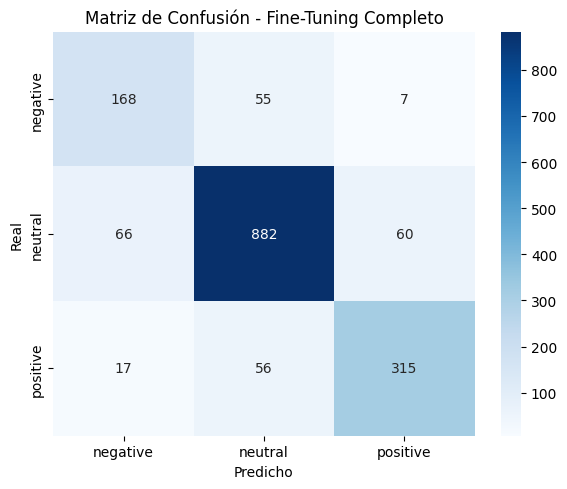

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

predictions = trainer.predict(test_tok)
preds = predictions.predictions.argmax(axis=-1)
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(labels, preds, target_names=['negative', 'neutral', 'positive']))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Matriz de Confusión - Fine-Tuning Completo')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=150)
plt.show()

In [17]:
labels_bin = label_binarize(labels, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs, multi_class='ovr', average='weighted')
print(f"ROC-AUC (weighted OvR): {auc:.4f}")

ROC-AUC (weighted OvR): 0.9347


In [24]:
model_path = '../models/finbert_rslora_finetuned'
model_size = sum(
    os.path.getsize(os.path.join(model_path, f))
    for f in os.listdir(model_path) if os.path.isfile(os.path.join(model_path, f))
) / (1024 ** 2)
print(f"\nTamaño del modelo en disco: {model_size:.3f} MB")


Tamaño del modelo en disco: 1.830 MB


In [19]:
# Función de inferencia: devuelve logits y probabilidades para nuevos textos
def predict_texts(texts, model, tokenizer, max_length=128):
    if isinstance(texts, str):
        texts = [texts]

    device = model.device
    enc = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length,
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    model.eval()
    with torch.no_grad():
        out = model(**enc)
        logits = out.logits
        probs = torch.softmax(logits, dim=-1)

    logits_np = logits.cpu().numpy()
    probs_np = probs.cpu().numpy()
    pred_ids = probs_np.argmax(axis=-1)

    results = []
    for i, txt in enumerate(texts):
        results.append({
            "text": txt,
            "logits": logits_np[i].tolist(),
            "probabilities": probs_np[i].tolist(),
            "predicted_label_id": int(pred_ids[i]),
            "predicted_label": ID2LABEL[int(pred_ids[i])],
        })
    return results

In [20]:
# Ejemplos de uso con predicciones
example_texts = [
    "Goldman Sachs stock price target raised to $367 from $358 at Oppenheimer",
    "Baltic Dry Index sheds 5%",
    "Ocean impact investment fund reaches $92m second close",
]

preds = predict_texts(example_texts, trainer.model, tokenizer)
for p in preds:
    print("-" * 100)
    print("Text:", p["text"])
    print("Logits [neg, neu, pos]:", np.round(p["logits"], 4))
    print("Probabilidades [neg, neu, pos]:", np.round(p["probabilities"], 4))
    print("Predicción:", p["predicted_label"])

----------------------------------------------------------------------------------------------------
Text: Goldman Sachs stock price target raised to $367 from $358 at Oppenheimer
Logits [neg, neu, pos]: [-1.9995 -2.4861  3.3593]
Probabilidades [neg, neu, pos]: [0.0047 0.0029 0.9925]
Predicción: positive
----------------------------------------------------------------------------------------------------
Text: Baltic Dry Index sheds 5%
Logits [neg, neu, pos]: [ 2.5954 -0.2058 -1.7592]
Probabilidades [neg, neu, pos]: [0.9315 0.0566 0.012 ]
Predicción: negative
----------------------------------------------------------------------------------------------------
Text: Ocean impact investment fund reaches $92m second close
Logits [neg, neu, pos]: [-2.5267  2.1599  0.0276]
Probabilidades [neg, neu, pos]: [0.0082 0.8867 0.1051]
Predicción: neutral


In [21]:
def compute_ece(probs, labels, n_bins=10):
    confidences = probs.max(axis=-1)
    correct = (probs.argmax(axis=-1) == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = sum(
        abs(correct[mask].mean() - confidences[mask].mean()) * mask.sum()
        for i in range(n_bins)
        if (mask := (confidences > bins[i]) & (confidences <= bins[i+1])).sum() > 0
    )
    return ece / len(labels)

print(f"ECE (calibración):      {compute_ece(probs, labels):.4f}  (0 = perfecto)")

ECE (calibración):      0.0464  (0 = perfecto)


In [22]:
import math

test_loss = predictions.metrics.get('test_loss', None)
if test_loss:
    ppl_approx = math.exp(test_loss)
    print(f"Pseudo-Perplexity (aprox. via test loss): {ppl_approx:.4f}")

Pseudo-Perplexity (aprox. via test loss): 1.5275


In [23]:
# Guardado del modelo finetuneado
SAVE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "finbert_rslora_finetuned"))
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Modelo y tokenizer guardados en: {SAVE_DIR}")

Modelo y tokenizer guardados en: /models/finbert_rslora_finetuned
